In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(compositions)
library(ecodist)
library(cowplot)

── Attaching core tidyverse packages ─────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ───────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Welcome to compositions, a package for compositional data analysis.yverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conf

# File Ordering==================================================================================

In [2]:
# Read taxa data
taxa_tab_tp2 <- read.table("/ceph/projects/010_SweMaMi/bm.nowak/data/tp2_taxa_fp_sp__42_250909.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote='"') 
dim(taxa_tab_tp2)
head(taxa_tab_tp2)

[1] 984  42

,100000112243,100000133958,100000418123,100000168325,100000129494,100000126820,100000123362,100000126714,100000421192,100000427415,⋯,100000426050,100000433645,100000106303,100000106341,100000103470,100000106136,100000108482,100000157503,100000148082,100000148693
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Acidaminococcus intestini,0.00000,1.32773,0.00000,0,0,0.00000,0,0.00000,0.00000,0.00000,⋯,0,0.00000,0.00000,0.00000,0e+00,0.00000,0.00000,0.00000,0.00000,0.0000
Acinetobacter SGB65105,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,0.00000,⋯,0,0.00000,0.00000,0.00000,0e+00,0.00000,0.00000,0.05408,0.00000,0.0000
Actinobaculum sp_oral_taxon_183,0.00000,0.00000,0.00000,0,0,0.00010,0,0.00000,0.00000,0.00000,⋯,0,0.00000,0.00000,0.00000,0e+00,0.00000,0.00000,0.00000,0.00000,0.0000
Actinomyces bouchesdurhonensis,0.00000,0.00000,0.00000,0,0,0.00674,0,0.00000,0.00000,0.00073,⋯,0,0.00000,0.00000,0.00188,7e-05,0.00000,0.00492,0.00222,0.00059,0.0000
Actinomyces graevenitzii,0.00211,0.00000,0.00203,0,0,0.00000,0,0.00279,0.00143,0.00254,⋯,0,0.00695,0.00094,0.00045,0e+00,0.00093,0.00036,0.00000,0.00032,0.0011
Actinomyces naeslundii,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,0.00234,⋯,0,0.00258,0.00000,0.00000,0e+00,0.00000,0.00000,0.00000,0.00000,0.0000


In [3]:
tail(taxa_tab_tp2)

,100000112243,100000133958,100000418123,100000168325,100000129494,100000126820,100000123362,100000126714,100000421192,100000427415,⋯,100000426050,100000433645,100000106303,100000106341,100000103470,100000106136,100000108482,100000157503,100000148082,100000148693
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Vescimonas SGB15086,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Vescimonas SGB15087,0.00359,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.02664,0.00000,0.00000
Victivallis lenta,0.01133,0.00000,0.00000,0.00000,0.00000,0.02110,0.00000,0.00000,0.00000,0.07131,⋯,0.00036,0.00000,0.00000,0.24265,0.00000,0.00000,0.05986,0.02399,0.00000,0.00000
Victivallis vadensis,0.00000,0.01186,0.00000,0.00000,0.00000,0.00000,0.00000,0.02922,0.00000,0.00816,⋯,0.00128,0.00000,0.00000,0.00000,0.00000,0.00000,0.03990,0.00413,0.18357,0.00000
Waltera intestinalis,0.00387,0.05861,0.00700,0.01722,0.05579,0.00000,0.22885,0.00157,0.08619,3.50011,⋯,0.99393,0.00689,0.01219,0.94727,4.47788,0.02220,1.28550,0.05965,0.02656,0.00211
Other_taxa,2.47230,5.82934,0.86371,0.42482,1.55244,1.72654,1.59920,0.44751,0.70347,2.20868,⋯,0.88001,11.28523,1.17631,0.57416,7.19169,1.02617,1.28246,3.29574,4.33514,1.62319


In [4]:
# Check that all columns are equal to 100
apply(taxa_tab_tp2, 2, sum)

100000112243 100000133958 100000418123 100000168325 100000129494 100000126820 
         100          100          100          100          100          100 
100000123362 100000126714 100000421192 100000427415 100000426753 100000433799 
         100          100          100          100          100          100 
100000406809 100000136430 100000140093 100000144381 100000417232 100000189313 
         100          100          100          100          100          100 
100000185766 100000155653 100000172865 100000408391 100000134894 100000420362 
         100          100          100          100          100          100 
100000172728 100000186718 100000426708 100000422069 100000429761 100000434772 
         100          100          100          100          100          100 
100000424926 100000421864 100000426050 100000433645 100000106303 100000106341 
         100          100          100          100          100          100 
100000103470 100000106136 100000108482 100000157503 100000148082 100000148693 
         100          100          100          100          100          100

In [5]:
#?as.data.frame

In [6]:
# Reorder taxa so columns become rows and vice versa
taxa_df_tp2 <- as.data.frame(t(taxa_tab_tp2))
head(taxa_df_tp2)

,Acidaminococcus intestini,Acinetobacter SGB65105,Actinobaculum sp_oral_taxon_183,Actinomyces bouchesdurhonensis,Actinomyces graevenitzii,Actinomyces naeslundii,Actinomyces oris,Actinomyces SGB17132,Actinomyces SGB17154,Actinomyces SGB17157,⋯,Veillonella parvula,Veillonella rogosae,Vescimonas coprocola,Vescimonas fastidiosa,Vescimonas SGB15086,Vescimonas SGB15087,Victivallis lenta,Victivallis vadensis,Waltera intestinalis,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100000112243,0.00000,0,0e+00,0.00000,0.00211,0,0.00082,0.00000,0.00247,0,⋯,0.00234,0,0.01998,0,0,0.00359,0.01133,0.00000,0.00387,2.47230
100000133958,1.32773,0,0e+00,0.00000,0.00000,0,0.00000,0.00000,0.00000,0,⋯,0.00000,0,0.10240,0,0,0.00000,0.00000,0.01186,0.05861,5.82934
100000418123,0.00000,0,0e+00,0.00000,0.00203,0,0.00000,0.00000,0.00000,0,⋯,0.00025,0,0.19758,0,0,0.00000,0.00000,0.00000,0.00700,0.86371
100000168325,0.00000,0,0e+00,0.00000,0.00000,0,0.00100,0.00000,0.00000,0,⋯,0.00000,0,0.11860,0,0,0.00000,0.00000,0.00000,0.01722,0.42482
100000129494,0.00000,0,0e+00,0.00000,0.00000,0,0.00000,0.00000,0.00000,0,⋯,0.00000,0,0.10710,0,0,0.00000,0.00000,0.00000,0.05579,1.55244
100000126820,0.00000,0,1e-04,0.00674,0.00000,0,0.00159,0.00064,0.00967,0,⋯,0.00000,0,0.00621,0,0,0.00000,0.02110,0.00000,0.00000,1.72654


In [7]:
# Read metadata
combined_meta_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/2025-09-01_combined_fp_sp_tp2.csv", header = TRUE, row.names = 1)
head(combined_meta_tp2)
dim(combined_meta_tp2)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,4,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,3,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,First pregnancy
5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,3,⋯,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0,First pregnancy
5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,3,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,4,⋯,NA,NA,NA,NA,38,Induction,NA,NA,0,First pregnancy


[1]  42 566

In [8]:
# Clean whitespace and convert to char
combined_meta_tp2$Group <- trimws(as.character(combined_meta_tp2$Group))
head(combined_meta_tp2)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,4,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,3,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,First pregnancy
5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,3,⋯,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0,First pregnancy
5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,3,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,4,⋯,NA,NA,NA,NA,38,Induction,NA,NA,0,First pregnancy


In [9]:
# Choose variables of interest
variables_tp2 <- combined_meta_tp2 |>
    select(Group, Studienummer, Q1_Personnummer, age_checked, Age_groups, excess_weight, Weight_before_C, BMI_prior, kit2.faecal_sample.barcode, Primipara,
          Q2_X25_Smoking_snus_now, Q2_X28_How_often_alcohol_since_pregnancy, Q2_X6.Antibiotics_during_pregnancy, stress_sum_score_Q2)

In [10]:
# Group bmi groups
bmi_levels <- c("< 18.5 Underweight", "18.5-25 Normal weight", "> 25 Overweight")
bmi_levels
variables_tp2$BMI_groups <- factor(variables_tp2$BMI_prior, levels = bmi_levels)
class(variables_tp2$BMI_groups)

[1] "< 18.5 Underweight"    "18.5-25 Normal weight" "> 25 Overweight"

[1] "factor"

In [11]:
head(variables_tp2)

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit2.faecal_sample.barcode,Primipara,Q2_X25_Smoking_snus_now,Q2_X28_How_often_alcohol_since_pregnancy,Q2_X6.Antibiotics_during_pregnancy,stress_sum_score_Q2,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000144381,1,Nej,Aldrig,0,1,NA
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000172865,1,Nej,Aldrig,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000112243,1,Nej,Aldrig,0,4,NA
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000168325,1,Nej,Aldrig,0,5,NA
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,100000123362,1,Nej,Aldrig,1,8,NA
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,100000106341,1,Nej,Aldrig,0,6,NA


In [12]:
# Convert to fitting data types
variables_tp2$excess_weight <- as.factor(variables_tp2$excess_weight)
class(variables_tp2$excess_weight)

variables_tp2$kit2.faecal_sample.barcode <- as.character(variables_tp2$kit2.faecal_sample.barcode)
class(variables_tp2$kit2.faecal_sample.barcode)

variables_tp2$Primipara <- as.factor(variables_tp2$Primipara)
class(variables_tp2$Primipara)

head(variables_tp2)

[1] "factor"

[1] "character"

[1] "factor"

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit2.faecal_sample.barcode,Primipara,Q2_X25_Smoking_snus_now,Q2_X28_How_often_alcohol_since_pregnancy,Q2_X6.Antibiotics_during_pregnancy,stress_sum_score_Q2,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000144381,1,Nej,Aldrig,0,1,NA
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000172865,1,Nej,Aldrig,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000112243,1,Nej,Aldrig,0,4,NA
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000168325,1,Nej,Aldrig,0,5,NA
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,100000123362,1,Nej,Aldrig,1,8,NA
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,100000106341,1,Nej,Aldrig,0,6,NA


In [13]:
# Convert smoking to categories 
smoking_category <- ifelse(variables_tp2$Q2_X25_Smoking_snus_now == "Nej", 0, ifelse(variables_tp2$Q2_X25_Smoking_snus_now == "Ja", 1, NA))
(smoking_category)
variables_tp2$Q2_X25_Smoking_snus_now <- as.factor(smoking_category)
head(variables_tp2)

[1]  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
[26]  0  0  0  0  0  0  0  0 NA  0  0  0  0  0 NA  0  0

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit2.faecal_sample.barcode,Primipara,Q2_X25_Smoking_snus_now,Q2_X28_How_often_alcohol_since_pregnancy,Q2_X6.Antibiotics_during_pregnancy,stress_sum_score_Q2,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<chr>,<int>,<int>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000144381,1,0,Aldrig,0,1,NA
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000172865,1,0,Aldrig,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000112243,1,0,Aldrig,0,4,NA
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000168325,1,0,Aldrig,0,5,NA
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,100000123362,1,0,Aldrig,1,8,NA
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,100000106341,1,0,Aldrig,0,6,NA


In [14]:
#variables_tp2$Q2_X28_How_often_alcohol_since_pregnancy
# Convert alcohol to categories 
alcohol_category <- ifelse(variables_tp2$Q2_X28_How_often_alcohol_since_pregnancy == "Aldrig", 0, 
                           ifelse(variables_tp2$Q2_X28_How_often_alcohol_since_pregnancy == "Ja", 1, NA))
alcohol_category
variables_tp2$Q2_X28_How_often_alcohol_since_pregnancy <- as.factor(alcohol_category)
head(variables_tp2)

[1]  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
[26]  0  0  0  0  0  0  0  0  0  0  0  0  0  0 NA  0  0

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit2.faecal_sample.barcode,Primipara,Q2_X25_Smoking_snus_now,Q2_X28_How_often_alcohol_since_pregnancy,Q2_X6.Antibiotics_during_pregnancy,stress_sum_score_Q2,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<int>,<int>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000144381,1,0,0,0,1,NA
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000172865,1,0,0,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000112243,1,0,0,0,4,NA
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000168325,1,0,0,0,5,NA
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,100000123362,1,0,0,1,8,NA
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,100000106341,1,0,0,0,6,NA


In [15]:
# Convert antibiotics to fct
variables_tp2$Q2_X6.Antibiotics_during_pregnancy <- as.factor(variables_tp2$Q2_X6.Antibiotics_during_pregnancy)
class(variables_tp2$Q2_X6.Antibiotics_during_pregnancy)
head(variables_tp2$Q2_X6.Antibiotics_during_pregnancy )

[1] "factor"

[1] 0 0 0 0 1 0
Levels: 0 1

In [16]:
# Stress into categories
high_stress <- ifelse(variables_tp2$stress_sum_score_Q2 >= 7, 1, ifelse(variables_tp2$stress_sum_score_Q2 < 7 , 0, NA))
high_stress
length(variables_tp2$stress_sum_score_Q2)


[1] 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0
[39] 0 0 0 0

[1] 42

In [17]:
variables_tp2$stress_sum_score_Q2 <- as.factor(high_stress)
class(variables_tp2$stress_sum_score_Q2)
head(variables_tp2$stress_sum_score_Q2)

[1] "factor"

[1] 0 0 0 0 1 0
Levels: 0 1

In [18]:
# Create a table with relevant variables
adonis_tab_tp2 <- variables_tp2 |> rename(Studynumber = Studienummer, Personalnumber = Q1_Personnummer, Age = age_checked, 
                                          Sample_ID = kit2.faecal_sample.barcode, Smoking = Q2_X25_Smoking_snus_now, 
                                          Alcohol = Q2_X28_How_often_alcohol_since_pregnancy, Antibiotics = Q2_X6.Antibiotics_during_pregnancy,
                                          High_stress = stress_sum_score_Q2)
head(adonis_tab_tp2)

,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000144381,1,0,0,0,0,NA
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000172865,1,0,0,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000112243,1,0,0,0,0,NA
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000168325,1,0,0,0,0,NA
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,100000123362,1,0,0,1,1,NA
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,100000106341,1,0,0,0,0,NA


In [19]:
# Rename groups for ease of reading plots
adonis_tab_tp2$Group <- ifelse(adonis_tab_tp2$Group == "First pregnancy", "Nulliparous", 
                                   ifelse(adonis_tab_tp2$Group == "Second pregnancy", "Primiparous", NA))
head(adonis_tab_tp2)

,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,100000144381,1,0,0,0,0,NA
5297,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,100000172865,1,0,0,0,0,NA
5301,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,100000112243,1,0,0,0,0,NA
5275,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,100000168325,1,0,0,0,0,NA
5243,Nulliparous,S39fe1d7,P3db7da6,29,2,No,55,21,100000123362,1,0,0,1,1,NA
5383,Nulliparous,S7e4a963,P424fd61,37,4,No,67,24,100000106341,1,0,0,0,0,NA


In [20]:
adonis_tab_tp2$Group <- as.factor(adonis_tab_tp2$Group)
class(adonis_tab_tp2$Group)
#head(adonis_tab_tp2)

[1] "factor"

In [21]:
# Order taxa according to meta data file, so they are in the same order
# ```factor``` to convert rownames and adonis to deffine order

ordered_taxa_tp2 <- taxa_df_tp2 |> 
    arrange(factor(rownames(taxa_df_tp2), level = adonis_tab_tp2$Sample_ID))

#ordered_taxa <- taxa |> arrange(factor(rownames(taxa), level = adonis_tab$Sample_ID))


adonis_tab_tp2$Sample_ID
head(ordered_taxa_tp2)
head(adonis_tab_tp2)
head(adonis_tab_tp2$Sample_ID)
dim(ordered_taxa_tp2)

[1] "100000144381" "100000172865" "100000112243" "100000168325" "100000123362"
 [6] "100000106341" "100000172728" "100000129494" "100000106136" "100000136430"
[11] "100000126714" "100000155653" "100000133958" "100000148082" "100000126820"
[16] "100000140093" "100000134894" "100000108482" "100000106303" "100000148693"
[21] "100000103470" "100000433799" "100000426708" "100000157503" "100000424926"
[26] "100000189313" "100000426753" "100000422069" "100000421192" "100000417232"
[31] "100000420362" "100000408391" "100000427415" "100000406809" "100000421864"
[36] "100000429761" "100000434772" "100000433645" "100000426050" "100000185766"
[41] "100000418123" "100000186718"

,Acidaminococcus intestini,Acinetobacter SGB65105,Actinobaculum sp_oral_taxon_183,Actinomyces bouchesdurhonensis,Actinomyces graevenitzii,Actinomyces naeslundii,Actinomyces oris,Actinomyces SGB17132,Actinomyces SGB17154,Actinomyces SGB17157,⋯,Veillonella parvula,Veillonella rogosae,Vescimonas coprocola,Vescimonas fastidiosa,Vescimonas SGB15086,Vescimonas SGB15087,Victivallis lenta,Victivallis vadensis,Waltera intestinalis,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100000144381,0,0,0,0.00445,0.00103,0.00014,0.00060,0.00000,0.00000,0,⋯,0.06635,0.02263,0.16424,0.05982,0,0.00000,0.00000,0,4.37013,0.83921
100000172865,0,0,0,0.00000,0.00044,0.00000,0.00094,0.00038,0.00000,0,⋯,0.04345,0.00338,0.35493,0.00000,0,0.00000,0.00000,0,0.00404,1.26158
100000112243,0,0,0,0.00000,0.00211,0.00000,0.00082,0.00000,0.00247,0,⋯,0.00234,0.00000,0.01998,0.00000,0,0.00359,0.01133,0,0.00387,2.47230
100000168325,0,0,0,0.00000,0.00000,0.00000,0.00100,0.00000,0.00000,0,⋯,0.00000,0.00000,0.11860,0.00000,0,0.00000,0.00000,0,0.01722,0.42482
100000123362,0,0,0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,⋯,0.00000,0.00000,0.02722,0.00000,0,0.00000,0.00000,0,0.22885,1.59920
100000106341,0,0,0,0.00188,0.00045,0.00000,0.00158,0.00000,0.00463,0,⋯,0.00264,0.00000,0.62222,0.00000,0,0.00000,0.24265,0,0.94727,0.57416


,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,100000144381,1,0,0,0,0,NA
5297,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,100000172865,1,0,0,0,0,NA
5301,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,100000112243,1,0,0,0,0,NA
5275,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,100000168325,1,0,0,0,0,NA
5243,Nulliparous,S39fe1d7,P3db7da6,29,2,No,55,21,100000123362,1,0,0,1,1,NA
5383,Nulliparous,S7e4a963,P424fd61,37,4,No,67,24,100000106341,1,0,0,0,0,NA


[1] "100000144381" "100000172865" "100000112243" "100000168325" "100000123362"
[6] "100000106341"

[1]  42 984

In [22]:
intersect((rownames(ordered_taxa_tp2)), adonis_tab_tp2$Sample_ID) |> length()

[1] 42

In [23]:
# Find mismatches
which_mismatch <- which(rownames(ordered_taxa_tp2) != adonis_tab_tp2$Sample_ID)

# Show the differences
data.frame(
      taxa_row = rownames(ordered_taxa_tp2)[which_mismatch],
  metadata_id = adonis_tab_tp2$Sample_ID[which_mismatch]
)

taxa_row,metadata_id
<chr>,<chr>


# Jaccard Distance============================================================================

In [24]:
# pa to scale x (taxa?) to presence or absence (1/0) - purpose of Jaccard
# vegdist picks method
jaccard_tp2 <- ordered_taxa_tp2 |>
    decostand(method = "pa") |>          
  vegdist(method = "jaccard")
head(jaccard_tp2)

[1] 0.5680191 0.5869074 0.6130435 0.5990676 0.5119826 0.5381356

In [25]:
jaccard_pcoa_tp2 <-wcmdscale(jaccard_tp2, eig = TRUE, add = TRUE)
jaccard_points_tp2 <- data.frame(jaccard_pcoa_tp2$points)
head(jaccard_points_tp2)

,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,Dim10,⋯,Dim32,Dim33,Dim34,Dim35,Dim36,Dim37,Dim38,Dim39,Dim40,Dim41
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100000144381,-0.10427594,0.15539093,0.16215112,-0.07503262,0.009794947,0.01554785,0.08015297,-0.08748592,0.03142789,0.10531677,⋯,0.023941601,-0.028176828,-0.009435111,0.01069805,-0.011810690,0.0103428833,0.009165341,-0.0027653832,-0.0033567488,3.628407e-03
100000172865,0.04514248,0.10190059,0.02852646,-0.11009523,-0.014773074,-0.03251380,0.08154939,-0.03230328,0.05746614,0.05318179,⋯,-0.007046585,0.001695692,0.001238690,-0.01481226,0.006510754,-0.0006512069,0.004217004,-0.0014854425,0.0006525794,-2.094484e-04
100000112243,-0.12850061,0.26752019,-0.05568973,0.12108389,0.041205367,-0.10671542,-0.06276595,-0.02059259,-0.01497751,0.05827177,⋯,0.004123151,-0.013877690,-0.082823695,0.07294919,-0.019461316,0.0063580557,-0.019312499,-0.0023360031,0.0053612039,-4.414895e-05
100000168325,0.01140862,-0.16456431,-0.00361613,0.09655437,0.076645431,0.12863538,-0.06918481,-0.13661965,0.14575914,-0.01024880,⋯,-0.006979939,0.007608072,-0.001589827,0.01078019,0.006604822,0.0069627043,0.001763404,0.0039972646,0.0048142849,-3.371318e-03
100000123362,0.08037476,0.04034486,-0.01833325,0.04976971,-0.045508043,0.06456459,-0.03157042,0.05259770,-0.02620504,-0.07960324,⋯,-0.016958082,0.004403091,-0.001056344,0.01914863,-0.001420690,0.0057621667,-0.005171921,0.0006854988,0.0022812780,-9.997126e-04
100000106341,-0.11960769,0.05937336,-0.01823840,-0.07554472,-0.111476990,0.06035392,0.12383331,0.05021897,0.06332008,-0.09925283,⋯,0.022988899,0.094982059,-0.029393276,-0.02341819,-0.018124162,0.0141474780,0.025649418,-0.0163606200,-0.0079739512,2.512491e-03


In [26]:
# Merge the points with metadata
jaccard_merged_tp2 <- jaccard_points_tp2 |>
  rownames_to_column(var = "Sample_ID") |>
  left_join(adonis_tab_tp2, by = "Sample_ID")
head(jaccard_merged_tp2) 

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,100000144381,-0.10427594,0.15539093,0.16215112,-0.07503262,0.009794947,0.01554785,0.08015297,-0.08748592,0.03142789,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,100000172865,0.04514248,0.10190059,0.02852646,-0.11009523,-0.014773074,-0.03251380,0.08154939,-0.03230328,0.05746614,⋯,3,No,55,21,1,0,0,0,0,NA
3,100000112243,-0.12850061,0.26752019,-0.05568973,0.12108389,0.041205367,-0.10671542,-0.06276595,-0.02059259,-0.01497751,⋯,3,Yes,67,25,1,0,0,0,0,NA
4,100000168325,0.01140862,-0.16456431,-0.00361613,0.09655437,0.076645431,0.12863538,-0.06918481,-0.13661965,0.14575914,⋯,3,No,56,21,1,0,0,0,0,NA
5,100000123362,0.08037476,0.04034486,-0.01833325,0.04976971,-0.045508043,0.06456459,-0.03157042,0.05259770,-0.02620504,⋯,2,No,55,21,1,0,0,1,1,NA
6,100000106341,-0.11960769,0.05937336,-0.01823840,-0.07554472,-0.111476990,0.06035392,0.12383331,0.05021897,0.06332008,⋯,4,No,67,24,1,0,0,0,0,NA


In [27]:
jaccard_dim1_tp2 <- round(jaccard_pcoa_tp2$eig[1]/sum(jaccard_pcoa_tp2$eig)*100, digits = 1)
jaccard_dim2_tp2 <- round(jaccard_pcoa_tp2$eig[1]/sum(jaccard_pcoa_tp2$eig)*100, digits = 1)
jaccard_dim1_tp2
jaccard_dim2_tp2

[1] 16.5

[1] 16.5

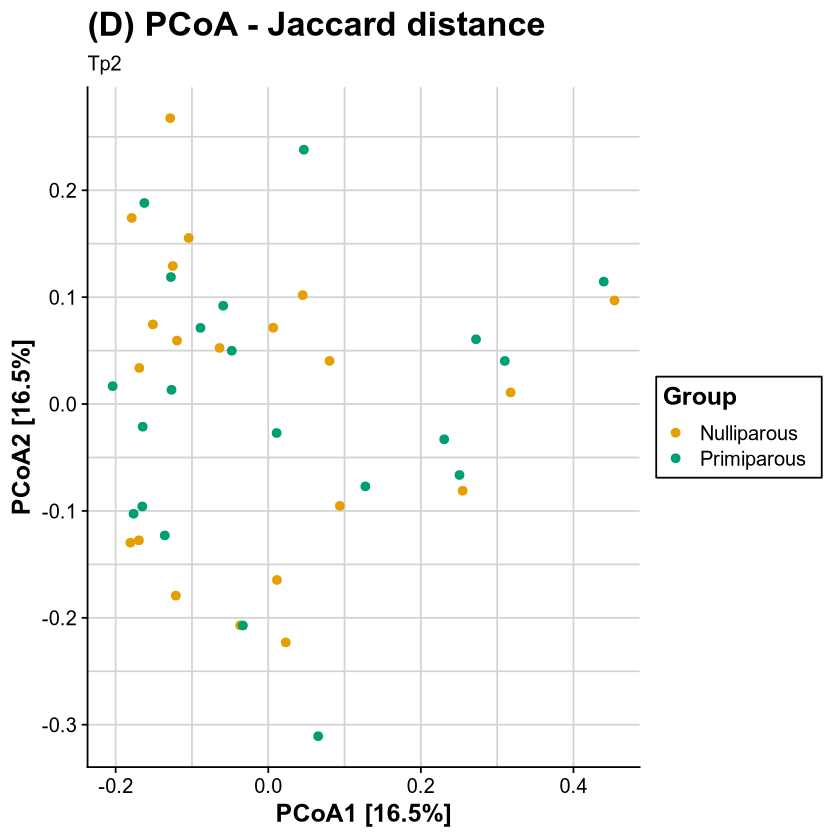

In [100]:
dye <- c("Nulliparous" = "#E69F00", "Primiparous" = "#009E73")

jaccard_plot_tp2 <- jaccard_merged_tp2 |>
    ggplot(aes(x = Dim1 , y = Dim2, color = Group)) +
    geom_point() +
    labs(
        x = paste0("PCoA1 [", jaccard_dim1_tp2, "%]"),
        y = paste0("PCoA2 [", jaccard_dim2_tp2, "%]"),
        title = "(D) PCoA - Jaccard distance",
        subtitle = "Tp2"
        
    ) +
    scale_color_manual(values = dye) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    )

jaccard_plot_tp2

## PERMANOVA----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [29]:
colnames(adonis_tab_tp2)

[1] "Group"           "Studynumber"     "Personalnumber"  "Age"            
 [5] "Age_groups"      "excess_weight"   "Weight_before_C" "BMI_prior"      
 [9] "Sample_ID"       "Primipara"       "Smoking"         "Alcohol"        
[13] "Antibiotics"     "High_stress"     "BMI_groups"

In [30]:
set.seed(123)
adonis_jac_group <- adonis2(formula = jaccard_tp2 ~ Group, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_jac_group)[1] <- "Group"
adonis_jac_group
jaccard_pval <- adonis_jac_group[1,"Pr(>F)"]
jaccard_pval

jaccard_r2 <- adonis_jac_group[1,"R2"]
jaccard_r2


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,0.06434565,0.007976969,0.3216445,1
Residual,40,8.00208372,0.992023031,NA,NA
Total,41,8.06642937,1.000000000,NA,NA


[1] 1

[1] 0.007976969

In [31]:
adonis_jac_age <- adonis2(formula = jaccard_tp2 ~ Age, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_jac_age)[1] <- "Age"
adonis_jac_age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.2752694,0.0341253,1.413239,0.073
Residual,40,7.7911600,0.9658747,NA,NA
Total,41,8.0664294,1.0000000,NA,NA


In [32]:
adonis_jac_agegroups <- adonis2(formula = jaccard_tp2 ~ Age_groups, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_jac_agegroups)[1] <- "Age_groups"
adonis_jac_agegroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_groups,1,0.2615553,0.03242517,1.340472,0.094
Residual,40,7.8048741,0.96757483,NA,NA
Total,41,8.0664294,1.00000000,NA,NA


In [33]:
adonis_jac_bmi <- adonis2(formula = jaccard_tp2 ~ BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_jac_bmi)[1] <- "BMI_prior"
adonis_jac_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_prior,1,0.3175222,0.03936341,1.639055,0.031
Residual,40,7.7489072,0.96063659,NA,NA
Total,41,8.0664294,1.00000000,NA,NA


In [34]:
adonis_jac_ab <- adonis2(formula = jaccard_tp2 ~ Antibiotics, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_jac_ab)[1] <- "Antibiotic"
adonis_jac_ab

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Antibiotic,1,0.3215861,0.04089925,1.66309,0.027
Residual,39,7.5413000,0.95910075,NA,NA
Total,40,7.8628861,1.00000000,NA,NA


In [35]:
adonis_jac_stress <- adonis2(formula = jaccard_tp2 ~ High_stress, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_jac_stress)[1] <- "High_stress"
adonis_jac_stress

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
High_stress,1,0.1688838,0.02093663,0.8553738,0.683
Residual,40,7.8975455,0.97906337,NA,NA
Total,41,8.0664294,1.00000000,NA,NA


In [36]:
    adonis_group_bmi <- adonis2(formula = jaccard_tp2 ~ Group + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_group_bmi)[1] <- "Group_BMI"
adonis_group_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_BMI,2,0.381748,0.04732553,0.9686916,0.521
Residual,39,7.684681,0.95267447,NA,NA
Total,41,8.066429,1.00000000,NA,NA


In [37]:
adonis_jac_group_weightbefore <- adonis2(formula = jaccard_tp2 ~ Group + Weight_before_C, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_jac_group_weightbefore)[1] <- "Group_weightBefore"
adonis_jac_group_weightbefore

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_weightBefore,2,0.3473924,0.04306645,0.8775904,0.742
Residual,39,7.7190369,0.95693355,NA,NA
Total,41,8.0664294,1.00000000,NA,NA


In [38]:
adonis_jac_agegroup_weight <- adonis2(formula = jaccard_tp2 ~ Age_groups + Weight_before_C, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_jac_agegroup_weight)[1] <- "AgeGroups_weightBefore"
adonis_jac_agegroup_weight

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_weightBefore,2,0.5454678,0.06762196,1.414263,0.036
Residual,39,7.5209616,0.93237804,NA,NA
Total,41,8.0664294,1.00000000,NA,NA


In [39]:
adonis_age_bmi <- adonis2(formula = jaccard_tp2 ~ Age + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_age_bmi)[1] <- "Age_BMI"
adonis_age_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_BMI,2,0.5964715,0.07394492,1.557063,0.011
Residual,39,7.4699579,0.92605508,NA,NA
Total,41,8.0664294,1.00000000,NA,NA


In [40]:
adonis_group_ab <- adonis2(formula = jaccard_tp2 ~ Group + Antibiotics, na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_group_ab)[1] <- "Group_antibiotics"
adonis_group_ab

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_antibiotics,2,0.3921333,0.04987142,0.9972933,0.447
Residual,38,7.4707528,0.95012858,NA,NA
Total,40,7.8628861,1.00000000,NA,NA


In [41]:
adonis_agegroup_bmi <- adonis2(formula = jaccard_tp2 ~ Age_groups + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_agegroup_bmi)[1] <- "AgeGroup_BMI"
adonis_agegroup_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroup_BMI,2,0.5795012,0.07184111,1.509334,0.015
Residual,39,7.4869281,0.92815889,NA,NA
Total,41,8.0664294,1.00000000,NA,NA


# Aitchison distance===============================================================================

In [42]:
aitchison_tp2 <- ordered_taxa_tp2 |>
   as.matrix() |>
    vegdist(method = "robust.aitchison")
head(aitchison_tp2)
head(as.matrix(aitchison_tp2))

[1] 20.669734 19.190333 34.684156 16.918987 23.615023  4.138432

,1,2,3,4,5,6,7,8,9,10,⋯,33,34,35,36,37,38,39,40,41,42
1,0.00000,20.66973,19.19033,34.68416,16.91899,23.61502,4.138432,27.72187,18.776143,19.095875,⋯,24.93625,32.769238,29.904113,35.04427,15.07897,29.294710,11.32163,26.67344,32.39396,27.754497
2,20.66973,0.00000,31.67336,15.85661,11.34350,19.79976,23.556082,12.50415,3.540041,19.772132,⋯,15.04954,12.906387,23.364873,20.72438,15.99514,19.667431,17.09231,10.13557,20.13225,9.360835
3,19.19033,31.67336,0.00000,45.36434,24.57668,40.96706,16.772379,31.57854,29.186960,37.915480,⋯,41.55294,41.327498,47.471195,46.00761,33.43838,45.343683,14.65628,32.75115,33.52251,34.602399
4,34.68416,15.85661,45.36434,0.00000,21.35514,22.66483,37.077337,17.21457,16.976344,27.622997,⋯,17.61223,6.590348,22.841737,10.00110,25.81886,17.121400,31.14273,14.10294,20.80681,12.573865
5,16.91899,11.34350,24.57668,21.35514,0.00000,21.66712,17.912441,12.55261,7.807962,22.933892,⋯,20.83881,18.632309,27.271759,21.58622,18.34885,23.180276,11.21237,11.20548,16.00200,13.202512
6,23.61502,19.79976,40.96706,22.66483,21.66712,0.00000,26.016713,29.38324,19.573873,8.996514,⋯,7.76742,25.676064,6.878071,20.42305,10.16300,7.562103,28.21483,25.94480,33.61533,25.887817


In [43]:
# Convert to matrix and re-assign proper row and column names since they did not transfer properly
aitchison_matrix_tp2 <- as.matrix(aitchison_tp2)
rownames(aitchison_matrix_tp2) <- rownames(ordered_taxa_tp2)
colnames(aitchison_matrix_tp2) <- rownames(ordered_taxa_tp2)
head(aitchison_matrix_tp2)

,100000144381,100000172865,100000112243,100000168325,100000123362,100000106341,100000172728,100000129494,100000106136,100000136430,⋯,100000427415,100000406809,100000421864,100000429761,100000434772,100000433645,100000426050,100000185766,100000418123,100000186718
100000144381,0.00000,20.66973,19.19033,34.68416,16.91899,23.61502,4.138432,27.72187,18.776143,19.095875,⋯,24.93625,32.769238,29.904113,35.04427,15.07897,29.294710,11.32163,26.67344,32.39396,27.754497
100000172865,20.66973,0.00000,31.67336,15.85661,11.34350,19.79976,23.556082,12.50415,3.540041,19.772132,⋯,15.04954,12.906387,23.364873,20.72438,15.99514,19.667431,17.09231,10.13557,20.13225,9.360835
100000112243,19.19033,31.67336,0.00000,45.36434,24.57668,40.96706,16.772379,31.57854,29.186960,37.915480,⋯,41.55294,41.327498,47.471195,46.00761,33.43838,45.343683,14.65628,32.75115,33.52251,34.602399
100000168325,34.68416,15.85661,45.36434,0.00000,21.35514,22.66483,37.077337,17.21457,16.976344,27.622997,⋯,17.61223,6.590348,22.841737,10.00110,25.81886,17.121400,31.14273,14.10294,20.80681,12.573865
100000123362,16.91899,11.34350,24.57668,21.35514,0.00000,21.66712,17.912441,12.55261,7.807962,22.933892,⋯,20.83881,18.632309,27.271759,21.58622,18.34885,23.180276,11.21237,11.20548,16.00200,13.202512
100000106341,23.61502,19.79976,40.96706,22.66483,21.66712,0.00000,26.016713,29.38324,19.573873,8.996514,⋯,7.76742,25.676064,6.878071,20.42305,10.16300,7.562103,28.21483,25.94480,33.61533,25.887817


In [44]:
aitchison_pcoa_tp2 <- wcmdscale(aitchison_matrix_tp2, eig = TRUE)

aitchison_points_tp2 <- data.frame(aitchison_pcoa_tp2$points)
head(aitchison_points_tp2)

,Dim1,Dim2,Dim3
,<dbl>,<dbl>,<dbl>
100000144381,-12.121751,14.890513,1.337044
100000172865,-1.934724,-1.108059,-6.879284
100000112243,-29.944408,8.464505,4.391256
100000168325,9.987511,-11.235382,-4.285131
100000123362,-7.418159,-1.271044,3.049482
100000106341,10.962501,10.201270,3.009656


In [45]:
aitchison_merged_tp2 <- aitchison_points_tp2 |>
    rownames_to_column(var = "Sample_ID") |>
    left_join(adonis_tab_tp2, by = "Sample_ID")
head(aitchison_merged_tp2)

,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,100000144381,-12.121751,14.890513,1.337044,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,NA
2,100000172865,-1.934724,-1.108059,-6.879284,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,1,0,0,0,0,NA
3,100000112243,-29.944408,8.464505,4.391256,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0,NA
4,100000168325,9.987511,-11.235382,-4.285131,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,0,NA
5,100000123362,-7.418159,-1.271044,3.049482,Nulliparous,S39fe1d7,P3db7da6,29,2,No,55,21,1,0,0,1,1,NA
6,100000106341,10.962501,10.201270,3.009656,Nulliparous,S7e4a963,P424fd61,37,4,No,67,24,1,0,0,0,0,NA


In [46]:
eig_val_tp2 <- aitchison_pcoa_tp2$eig
eig_val_tp2

[1] 6270.282 4712.729  794.647

In [47]:
# Save the eigenvalues, add percentages for plot
aitchison_dim1 <- round(aitchison_pcoa_tp2$eig[1]/sum(aitchison_pcoa_tp2$eig)*100, digits = 1)
aitchison_dim2 <- round(aitchison_pcoa_tp2$eig[2]/sum(aitchison_pcoa_tp2$eig)*100,  digits = 1)
aitchison_dim1
aitchison_dim2

[1] 53.2

[1] 40

In [48]:
aitchison_dim3 <- round(aitchison_pcoa_tp2$eig[3]/sum(aitchison_pcoa_tp2$eig)*100, digits = 1)
aitchison_dim4 <- round(aitchison_pcoa_tp2$eig[4]/sum(aitchison_pcoa_tp2$eig)*100,  digits = 1)
aitchison_dim3
aitchison_dim4

[1] 6.7

[1] NA

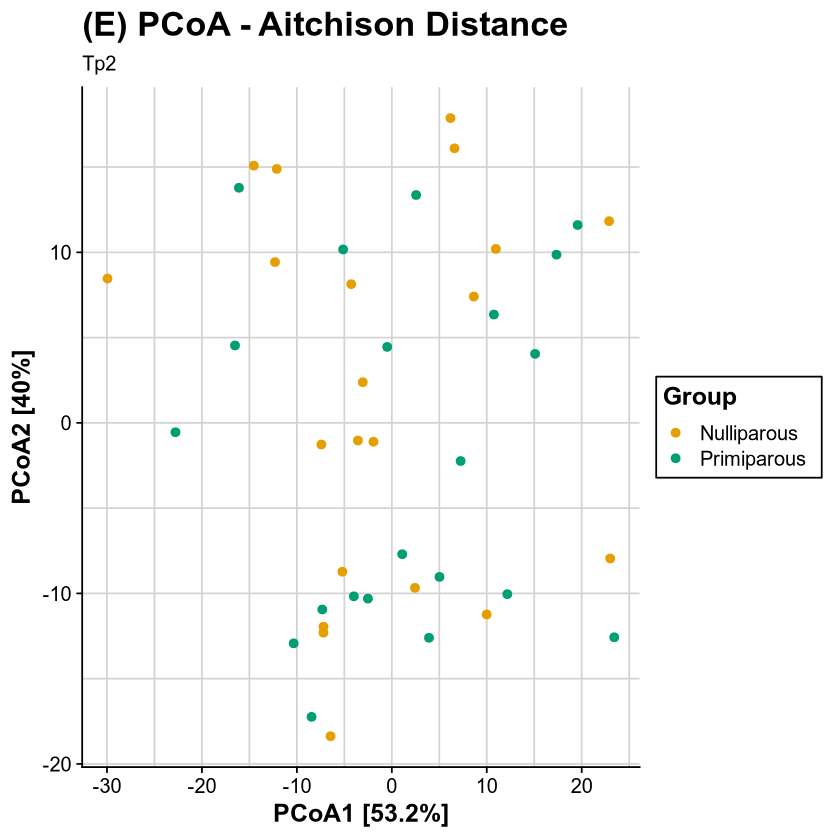

In [101]:
aitchison_plot_tp2 <- aitchison_merged_tp2 |>
    ggplot(aes(x = Dim1, y = Dim2, col = Group)) +
    geom_point() +
    scale_colour_manual(values = dye) +
    labs(
        x = paste0("PCoA1 [", aitchison_dim1, "%]"),
        y = paste0("PCoA2 [", aitchison_dim2, "%]"),
        title = "(E) PCoA - Aitchison Distance",
        subtitle = "Tp2"
    ) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    )

aitchison_plot_tp2 

## PERMANOVA----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [50]:
head(adonis_tab_tp2)

,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,100000144381,1,0,0,0,0,NA
5297,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,100000172865,1,0,0,0,0,NA
5301,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,100000112243,1,0,0,0,0,NA
5275,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,100000168325,1,0,0,0,0,NA
5243,Nulliparous,S39fe1d7,P3db7da6,29,2,No,55,21,100000123362,1,0,0,1,1,NA
5383,Nulliparous,S7e4a963,P424fd61,37,4,No,67,24,100000106341,1,0,0,0,0,NA


In [51]:
set.seed(123)
adonis_ait_group <- adonis2(formula = aitchison_tp2 ~ Group, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_group)[1] <- "Group"
adonis_ait_group
aitchison_pval <- adonis_ait_group[1,"Pr(>F)"]
aitchison_pval

aitchison_r2 <- adonis_ait_group[1,"R2"]
aitchison_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,197.7172,0.01678748,0.6829643,0.534
Residual,40,11579.9409,0.98321252,NA,NA
Total,41,11777.6581,1.00000000,NA,NA


[1] 0.534

[1] 0.01678748

In [52]:
#?adonis2

In [53]:
adonis_ait_age <- adonis2(formula = aitchison_tp2 ~ Age, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_age)[1] <- "Age"
adonis_ait_age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,285.3764,0.02423032,0.9932802,0.372
Residual,40,11492.2817,0.97576968,NA,NA
Total,41,11777.6581,1.00000000,NA,NA


In [54]:
adonis_ait_agegroup <- adonis2(formula = aitchison_tp2 ~ Age_groups, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_agegroup)[1] <- "Age_groups"
adonis_ait_agegroup

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_groups,1,291.9972,0.02479247,1.016911,0.357
Residual,40,11485.6609,0.97520753,NA,NA
Total,41,11777.6581,1.00000000,NA,NA


In [55]:
adonis_ait_excess <- adonis2(formula = aitchison_tp2 ~ excess_weight, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_excess)[1] <- "Excess_weight"
adonis_ait_excess

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Excess_weight,1,660.665,0.05859917,2.365377,0.102
Residual,38,10613.643,0.94140083,NA,NA
Total,39,11274.308,1.00000000,NA,NA


In [56]:
adonis_ait_weight <- adonis2(formula = aitchison_tp2 ~ Weight_before_C, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_weight)[1] <- "Weight_before"
adonis_ait_weight

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Weight_before,1,269.5209,0.02288409,0.9368013,0.382
Residual,40,11508.1372,0.97711591,NA,NA
Total,41,11777.6581,1.00000000,NA,NA


In [57]:
adonis_ait_bmi <- adonis2(formula = aitchison_tp2 ~ BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_bmi)[1] <- "BMI_prior"
adonis_ait_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_prior,1,314.9288,0.02673951,1.098966,0.36
Residual,40,11462.7293,0.97326049,NA,NA
Total,41,11777.6581,1.00000000,NA,NA


In [58]:
grep("BMI_groups", names(aitchison_tp2), value = TRUE)

character(0)

In [59]:
adonis_ait_ab  <- adonis2(formula = aitchison_tp2 ~ Antibiotics, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_ab)[1] <- "Antibiotics"
adonis_ait_ab

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Antibiotics,1,468.7199,0.04024371,1.635316,0.193
Residual,39,11178.3134,0.95975629,NA,NA
Total,40,11647.0333,1.00000000,NA,NA


In [60]:
adonis_ait_stress <- adonis2(formula = aitchison_tp2 ~ High_stress, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_stress)[1] <- "High_stress"
adonis_ait_stress

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
High_stress,1,11.80034,0.001001926,0.04011723,0.99
Residual,40,11765.85775,0.998998074,NA,NA
Total,41,11777.65809,1.000000000,NA,NA


In [61]:
adonis_ait_group_bmiprior <- adonis2(formula = aitchison_tp2 ~ Group + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_group_bmiprior)[1] <- "Group_bmi"
adonis_ait_group_bmiprior

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi,2,558.1243,0.0473884,0.9700425,0.442
Residual,39,11219.5338,0.9526116,NA,NA
Total,41,11777.6581,1.0000000,NA,NA


In [62]:
adonis_ait_group_weightbefore <- adonis2(formula = aitchison_tp2 ~ Group + Weight_before_C, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_group_weightbefore)[1] <- "Group_WeightBefore"
adonis_ait_group_weightbefore

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_WeightBefore,2,516.9118,0.04388919,0.8951255,0.468
Residual,39,11260.7462,0.95611081,NA,NA
Total,41,11777.6581,1.00000000,NA,NA


In [63]:
adonis_ait_agegroups_bmiprior <- adonis2(formula = aitchison_tp2 ~ Age_groups + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_agegroups_bmiprior)[1] <- "AgeGroups_bmiPrior"
adonis_ait_agegroups_bmiprior

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_bmiPrior,2,611.7716,0.0519434,1.068392,0.386
Residual,39,11165.8865,0.9480566,NA,NA
Total,41,11777.6581,1.0000000,NA,NA


In [64]:
adonis_ait_agegroup_weight <- adonis2(formula = aitchison_tp2 ~ Age_groups + Weight_before_C, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_agegroup_weight)[1] <- "AgeGroups_weightBefore"
adonis_ait_agegroup_weight

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_weightBefore,2,588.6816,0.04998291,1.025946,0.417
Residual,39,11188.9765,0.95001709,NA,NA
Total,41,11777.6581,1.00000000,NA,NA


In [65]:
adonis_ait_group_antibiotics <- adonis2(formula = aitchison_tp2 ~ Group + Antibiotics, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_group_antibiotics)[1] <- "Group_antibiotics"
adonis_ait_group_antibiotics

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_antibiotics,2,662.1171,0.05684856,1.145227,0.347
Residual,38,10984.9161,0.94315144,NA,NA
Total,40,11647.0333,1.00000000,NA,NA


In [66]:
adonis_ait_agegroup_bmi <- adonis2(formula = aitchison_tp2 ~ Age_groups + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_agegroup_bmi)[1] <- "AgeGroups_bmi"
adonis_ait_agegroup_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_bmi,2,611.7716,0.0519434,1.068392,0.368
Residual,39,11165.8865,0.9480566,NA,NA
Total,41,11777.6581,1.0000000,NA,NA


# Bray Curtis===================================================================================

In [67]:
bray_curt_dist_tp2 <- vegdist(ordered_taxa_tp2, method = "bray")
head(as.matrix(bray_curt_dist_tp2))

,100000144381,100000172865,100000112243,100000168325,100000123362,100000106341,100000172728,100000129494,100000106136,100000136430,⋯,100000427415,100000406809,100000421864,100000429761,100000434772,100000433645,100000426050,100000185766,100000418123,100000186718
100000144381,0.0000000,0.5584829,0.5242550,0.6185056,0.5641091,0.6823755,0.5156207,0.5768751,0.6696543,0.4825121,⋯,0.4817490,0.6745776,0.5575107,0.6624132,0.5576936,0.6721502,0.5874577,0.5457607,0.7017285,0.6833164
100000172865,0.5584829,0.0000000,0.6112315,0.5961450,0.6155435,0.7273896,0.7012010,0.5683687,0.6786050,0.5694863,⋯,0.5991414,0.6615339,0.5527239,0.6283414,0.6901214,0.7315228,0.6615399,0.5801942,0.6871817,0.5805799
100000112243,0.5242550,0.6112315,0.0000000,0.6584029,0.6127056,0.7073253,0.5733387,0.5894757,0.6496333,0.5540797,⋯,0.5909040,0.6884185,0.6261388,0.6648505,0.6200796,0.7784698,0.5218355,0.6668441,0.6881069,0.6764978
100000168325,0.6185056,0.5961450,0.6584029,0.0000000,0.7189964,0.7081727,0.6872399,0.6069029,0.7189749,0.6302684,⋯,0.5794172,0.6702459,0.5333377,0.6399253,0.6803570,0.6708220,0.7024132,0.5826212,0.6602506,0.6133460
100000123362,0.5641091,0.6155435,0.6127056,0.7189964,0.0000000,0.7026077,0.6224844,0.5736028,0.6963281,0.5629775,⋯,0.5823681,0.5926510,0.6578130,0.6488392,0.6356347,0.7487166,0.7087663,0.6471009,0.6750638,0.6193307
100000106341,0.6823755,0.7273896,0.7073253,0.7081727,0.7026077,0.0000000,0.6778901,0.7461208,0.6941944,0.6606171,⋯,0.6173941,0.7275856,0.6445595,0.6699666,0.6984653,0.7349758,0.7772633,0.7876101,0.7971391,0.7370818


In [68]:
bray_curt_pcoa_tp2 <- pco(bray_curt_dist_tp2)
#head(bray_curt_pcoa_tp2)

In [69]:
bray_vect_tp2 <- bray_curt_pcoa_tp2$vectors
bray_curt_merged_tp2 <- bray_vect_tp2 |>
    rownames_to_column(var = "Sample_ID") |>
    left_join(adonis_tab_tp2, by = "Sample_ID")
head(bray_curt_merged_tp2)

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,100000144381,-0.1681680499,0.14082310,-0.12020951,-0.04601324,-0.01220166,-0.011296720,-0.03704740,0.109900726,-0.02677928,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,100000172865,0.0416102679,0.06659320,0.03092386,0.03855434,-0.03713555,0.140022045,-0.14381769,-0.044333783,-0.09284274,⋯,3,No,55,21,1,0,0,0,0,NA
3,100000112243,-0.1472481267,0.23896595,0.07547240,0.09542600,0.02693655,-0.002495859,0.02634059,0.004284817,0.01155811,⋯,3,Yes,67,25,1,0,0,0,0,NA
4,100000168325,0.1376236697,-0.07421584,-0.09982778,0.18249476,-0.03573687,0.218488376,0.14811170,-0.068242834,0.05402089,⋯,3,No,56,21,1,0,0,0,0,NA
5,100000123362,0.0002766147,0.12689441,0.11352676,-0.18362005,-0.09367156,0.044027433,0.03601597,0.117852539,-0.18793219,⋯,2,No,55,21,1,0,0,1,1,NA
6,100000106341,-0.1322941749,-0.26078209,0.17797939,-0.06008052,0.17449688,0.057274931,0.12714519,0.180272065,-0.04441755,⋯,4,No,67,24,1,0,0,0,0,NA


In [70]:
# Save sample id's and X values to df
bray_df_tp2 <- data.frame(Sample_ID = bray_curt_merged_tp2[, 1],
                          Group = bray_curt_merged_tp2$Group,
                          pcoa1 = bray_curt_merged_tp2[, 2],
                          pcoa2 = bray_curt_merged_tp2[, 3],
                          pcoa3 = bray_curt_merged_tp2[, 4]
                         )
head(bray_df_tp2)

,Sample_ID,Group,pcoa1,pcoa2,pcoa3
,<chr>,<fct>,<dbl>,<dbl>,<dbl>
1,100000144381,Nulliparous,-0.1681680499,0.14082310,-0.12020951
2,100000172865,Nulliparous,0.0416102679,0.06659320,0.03092386
3,100000112243,Nulliparous,-0.1472481267,0.23896595,0.07547240
4,100000168325,Nulliparous,0.1376236697,-0.07421584,-0.09982778
5,100000123362,Nulliparous,0.0002766147,0.12689441,0.11352676
6,100000106341,Nulliparous,-0.1322941749,-0.26078209,0.17797939


In [71]:
# Save the eigenvalues, add percentages for plot
bray_dim1 <- round(bray_curt_pcoa_tp2$values[1]/sum(bray_curt_pcoa_tp2$values)*100, digits = 1)
bray_dim2 <- round(bray_curt_pcoa_tp2$values[2]/sum(bray_curt_pcoa_tp2$values)*100,  digits = 1)
bray_dim2
bray_dim1

[1] 9.6

[1] 12.3

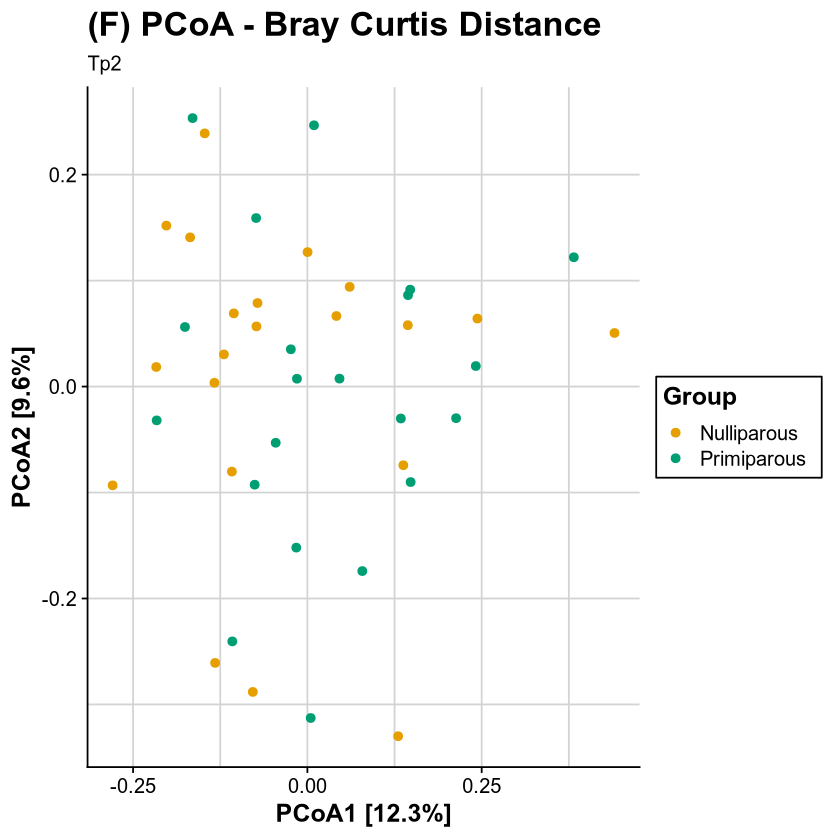

In [102]:
bray_plot_tp2 <- bray_df_tp2 |>
    ggplot(aes(x = pcoa1, y = pcoa2, col = Group)) +
    geom_point() +
    scale_colour_manual(values = dye) +
    labs(
        x = paste0("PCoA1 [", bray_dim1, "%]"),
        y = paste0("PCoA2 [", bray_dim2, "%]"),
        title = "(F) PCoA - Bray Curtis Distance",
        subtitle = "Tp2"
    ) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey") 
    )

bray_plot_tp2

## PERMANOVA------------------------------------------------------------------------------------------------------------------------------------------------------------

In [73]:
set.seed(123)
adonis_bray_group <- adonis2(formula = bray_curt_dist_tp2 ~ Group, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_group)[1] <- "Group"
adonis_bray_group
bray_pval <- adonis_bray_group[1,"Pr(>F)"]
bray_pval

bray_r2 <- adonis_bray_group[1,"R2"]
bray_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,0.1722725,0.01952693,0.7966329,0.793
Residual,40,8.6500313,0.98047307,NA,NA
Total,41,8.8223038,1.00000000,NA,NA


[1] 0.793

[1] 0.01952693

In [74]:
adonis_bray_age <- adonis2(formula = bray_curt_dist_tp2 ~ Age, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_age)[1] <- "Age"
adonis_bray_age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.2784758,0.03156498,1.303752,0.101
Residual,40,8.5438280,0.96843502,NA,NA
Total,41,8.8223038,1.00000000,NA,NA


In [75]:
adonis_bray_agegroup <- adonis2(formula = bray_curt_dist_tp2 ~ Age_groups, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_agegroup)[1] <- "Age_group"
adonis_bray_agegroup

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_group,1,0.2454341,0.02781972,1.144632,0.257
Residual,40,8.5768698,0.97218028,NA,NA
Total,41,8.8223038,1.00000000,NA,NA


In [76]:
adonis_ait_bmi <- adonis2(formula = bray_curt_dist_tp2 ~ BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_bmi)[1] <- "BMI_prior"
adonis_ait_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_prior,1,0.3375898,0.03826549,1.59152,0.028
Residual,40,8.4847140,0.96173451,NA,NA
Total,41,8.8223038,1.00000000,NA,NA


In [77]:
adonis_bray_ab <- adonis2(formula = bray_curt_dist_tp2 ~ Antibiotics, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_ab)[1] <- "Antibiotics"
adonis_bray_ab

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Antibiotics,1,0.2782874,0.03217824,1.296676,0.117
Residual,39,8.3700228,0.96782176,NA,NA
Total,40,8.6483103,1.00000000,NA,NA


In [78]:
adonis_bray_group_bmi <- adonis2(formula = bray_curt_dist_tp2 ~ Group + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_group_bmi)[1] <- "Group_bmi"
adonis_bray_group_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi,2,0.5183467,0.05875412,1.217222,0.115
Residual,39,8.3039571,0.94124588,NA,NA
Total,41,8.8223038,1.00000000,NA,NA


In [79]:
adonis_bray_group_weight <- adonis2(formula = bray_curt_dist_tp2 ~ Group + Weight_before_C, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_group_weight)[1] <- "Group_weight"
adonis_bray_group_weight

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_weight,2,0.5120323,0.05803839,1.20148,0.134
Residual,39,8.3102716,0.94196161,NA,NA
Total,41,8.8223038,1.00000000,NA,NA


In [80]:
adonis_bray_age_bmi <- adonis2(formula = bray_curt_dist_tp2 ~ Age + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_age_bmi)[1] <- "Age_bmi"
adonis_bray_age_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_bmi,2,0.6224403,0.07055303,1.480218,0.011
Residual,39,8.1998635,0.92944697,NA,NA
Total,41,8.8223038,1.00000000,NA,NA


In [81]:
adonis_bray_agegroup_bmi <- adonis2(formula = bray_curt_dist_tp2 ~ Age_groups + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_agegroup_bmi)[1] <- "AgeGroups_bmi"
adonis_bray_agegroup_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_bmi,2,0.5834471,0.06613319,1.380922,0.036
Residual,39,8.2388567,0.93386681,NA,NA
Total,41,8.8223038,1.00000000,NA,NA


In [82]:
adonis_bray_agegroup_weight <- adonis2(formula = bray_curt_dist_tp2 ~ Age_groups + Weight_before_C, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_agegroup_weight)[1] <- "AgeGroups_weightBefore"
adonis_bray_agegroup_weight

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_weightBefore,2,0.579455,0.06568069,1.370809,0.024
Residual,39,8.242849,0.93431931,NA,NA
Total,41,8.822304,1.00000000,NA,NA


# Exporting data======================================================================== 

In [83]:
#write.csv(jaccard_merged_tp2, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp2_nulliparous/tp2_alpha_beta_diversity/beta/", Sys.Date(),
 #                                           "_jaccard_merged_tp2", ".csv"), row.names = FALSE)

#write.csv(aitchison_merged_tp2, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp2_nulliparous/tp2_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_aitchison_merged_tp2", ".csv"), row.names = FALSE)

#write.csv(bray_curt_merged_tp2, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp2_nulliparous/tp2_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_bray_df_tp2", ".csv"), row.names = FALSE)

# Combined plot ------------------------------------------------------------------------------------------------------------

In [103]:
# Extract legend from bray plot
legend_bray <- get_legend(bray_plot_tp2)

In [104]:
# remove legends so only one remains
plot_jaccard_nl <- jaccard_plot_tp2 +  guides(fill = "none", color = "none") 
plot_aitch_nl <- aitchison_plot_tp2 +  guides(fill = "none", color = "none") 
plot_bray_nl <- bray_plot_tp2 +  guides(fill = "none", color = "none") 

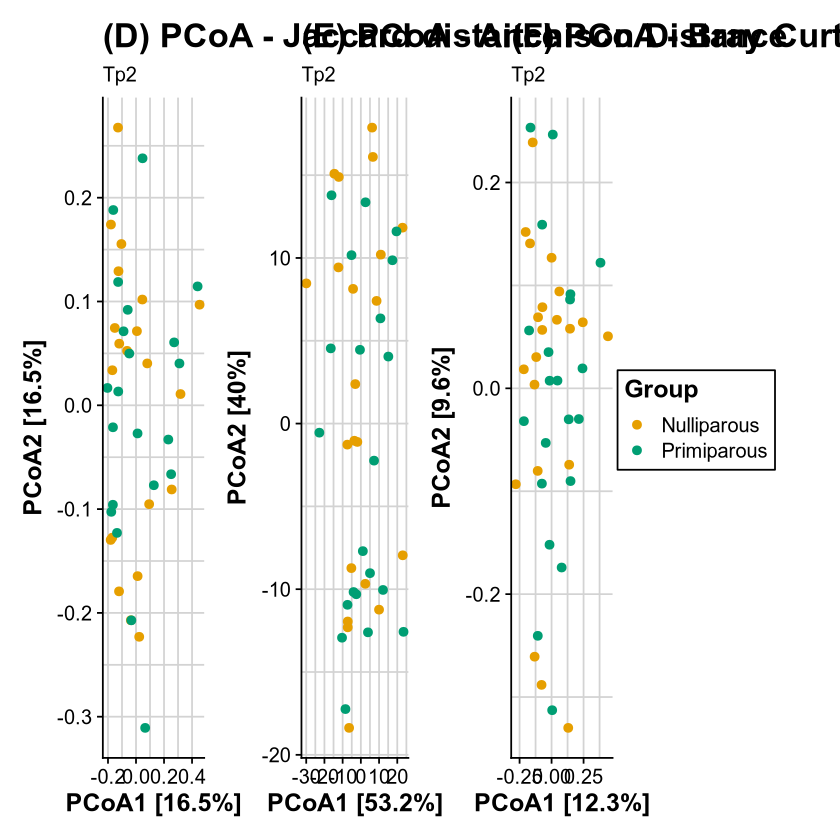

In [105]:
combined_plot <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, nrow =1) 

combined_plot_legend <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, legend_bray, nrow =1) 


final_plot <- ggdraw(combined_plot_legend) +
  theme_half_open() +
  background_grid() +
  theme(
    axis.text.x = element_blank(),
    plot.title = element_text(size = 15),
    axis.title = element_text(size = 15)
  )
final_plot

In [106]:
ggsave(file = paste0(Sys.Date(), "_gut_beta_tp2.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
       plot = final_plot, width = 19, height = 8)

# Bar plot ----------------------------------------------------------------------------

In [87]:
bar_df <- data.frame(
    Distance_metrics = c("Jaccard", "Aitchison", "Bray Curtis"),
    Pvalue = c(jaccard_pval, aitchison_pval, bray_pval),
    R2 = c(jaccard_r2, aitchison_r2, bray_r2)
)
bar_df

Distance_metrics,Pvalue,R2
<chr>,<dbl>,<dbl>
Jaccard,1.000,0.007976969
Aitchison,0.534,0.016787477
Bray Curtis,0.793,0.019526928


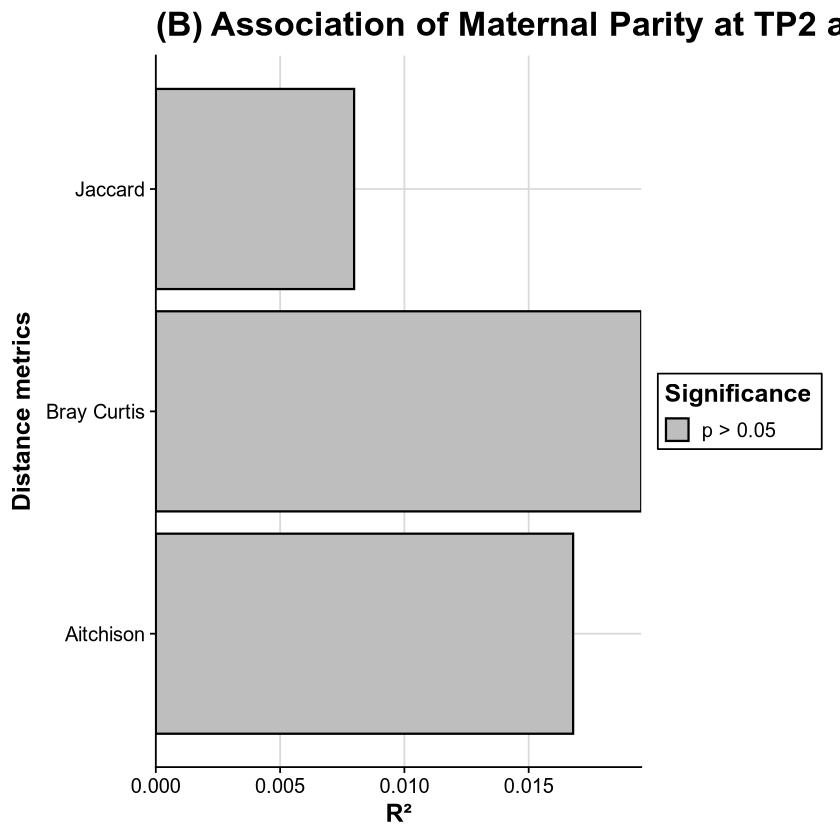

In [92]:
# Create column specifying p value greater or lesser
bar_df$Significance <- factor(ifelse(bar_df$Pvalue < 0.05, "p ≤ 0.05", "p > 0.05"))
dye_pval <- c("p ≤ 0.05" = "red", "p > 0.05" = "grey") # color vector 

#names(dye_pval) <- bar_df$Distance

bar_plot <- bar_df |>
    ggplot(aes(x = R2, y = Distance_metrics, fill = Significance)) +
    geom_col(colour = "black") +
    scale_fill_manual(values = dye_pval) +
    scale_x_continuous(expand = c(0, 0)) +   # removes gap
    labs(title = "(B) Association of Maternal Parity at TP2 across Distance Metrics for the Gut Microbiome",
        x = "R²",
        y = "Distance metrics") +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")) +
    background_grid()

bar_plot

In [93]:
ggsave(file = paste0(Sys.Date(), "_gut_beta_tp2_bar.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
       plot = bar_plot, width = 14, height = 8)